# CNN vs Transfer Learning untuk Klasifikasi Citra

**Tugas Individu — Mesin Learning 2**
**FarrelGhozy**

Eksperimen perbandingan dua pendekatan:
1. **CNN from scratch** — dataset CIFAR-10 (2 kelas)
2. **Transfer Learning** — dataset Cats vs Dogs dengan pretrained model

---
## Phase 1: Preprocessing & Augmentasi

### 1.1 Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import os
import time
import random
import zipfile
import urllib.request
import shutil
from pathlib import Path

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Library imported successfully")

I0000 00:00:1781751398.142739  454197 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781751398.470999  454197 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781751399.710289  454197 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
NumPy version: 2.4.6
Library imported successfully


---
## A. Dataset 1: CIFAR-10 (CNN from Scratch)

Menggunakan 2 kelas dari CIFAR-10. Pilihan: **cat (3) vs dog (5)**

In [2]:
# Load CIFAR-10 dari local dataset folder
import pickle

NOTEBOOK_DIR = os.getcwd()
if os.path.basename(NOTEBOOK_DIR) == 'notebook':
    NOTEBOOK_DIR = os.path.dirname(NOTEBOOK_DIR)
CIFAR_DIR = os.path.join(NOTEBOOK_DIR, 'dataset', 'cifar10')

def load_cifar10_local(data_dir=CIFAR_DIR):
    """Load CIFAR-10 dari local pickle files."""
    x_train_list, y_train_list = [], []
    
    # Load training batches
    for i in range(1, 6):
        batch_file = os.path.join(data_dir, f'data_batch_{i}')
        if os.path.exists(batch_file):
            with open(batch_file, 'rb') as f:
                batch = pickle.load(f, encoding='bytes')
            x_train_list.append(batch[b'data'])
            y_train_list.extend(batch[b'labels'])
    
    if not x_train_list:
        # Fallback: maybe only data_batch_1
        batch_file = os.path.join(data_dir, 'data_batch_1')
        if os.path.exists(batch_file):
            with open(batch_file, 'rb') as f:
                batch = pickle.load(f, encoding='bytes')
            x_train_list = [batch[b'data']]
            y_train_list = batch[b'labels']
    
    # Load test batch
    test_file = os.path.join(data_dir, 'test_batch')
    if os.path.exists(test_file):
        with open(test_file, 'rb') as f:
            test_batch = pickle.load(f, encoding='bytes')
        x_test = test_batch[b'data']
        y_test = test_batch[b'labels']
    else:
        raise FileNotFoundError(f"Test batch not found in {data_dir}")
    
    # Concatenate training data
    x_train = np.concatenate(x_train_list)
    y_train = np.array(y_train_list)
    y_test = np.array(y_test)
    
    # Reshape from (N, 3072) to (N, 32, 32, 3)
    x_train = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    x_test = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    
    return (x_train, y_train), (x_test, y_test)

print(f"Loading CIFAR-10 from {CIFAR_DIR}...")
(x_train_full, y_train_full), (x_test_full, y_test_full) = load_cifar10_local()

print("CIFAR-10 shape:", x_train_full.shape, x_test_full.shape)

# Pilih 2 kelas: cat (label 3) dan dog (label 5)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
selected_classes = [3, 5]  # cat, dog
selected_labels = ['cat', 'dog']

def filter_classes(x, y, classes):
    y = np.array(y)
    y = y.flatten() if y.ndim > 1 else y
    mask = np.isin(y, classes)
    x_filtered = x[mask]
    y_filtered = y[mask]
    y_binary = np.where(y_filtered == classes[0], 0, 1)
    return x_filtered, y_binary

x_train_cifar, y_train_cifar = filter_classes(x_train_full, y_train_full, selected_classes)
x_test_cifar, y_test_cifar = filter_classes(x_test_full, y_test_full, selected_classes)

print(f"CIFAR-10 (cat vs dog) — Train: {x_train_cifar.shape[0]}, Test: {x_test_cifar.shape[0]}")
print(f"Cat samples: {np.sum(y_train_cifar == 0)}, Dog samples: {np.sum(y_train_cifar == 1)}")

Loading CIFAR-10 from /home/fazy/Documents/01Semester5/Mesin Learning 2/CNN vs Transfer Learning untuk Klasifikasi Citra/dataset/cifar10...
CIFAR-10 shape: (50000, 32, 32, 3) (10000, 32, 32, 3)
CIFAR-10 (cat vs dog) — Train: 10000, Test: 2000
Cat samples: 5000, Dog samples: 5000


### Visualisasi Sampel CIFAR-10

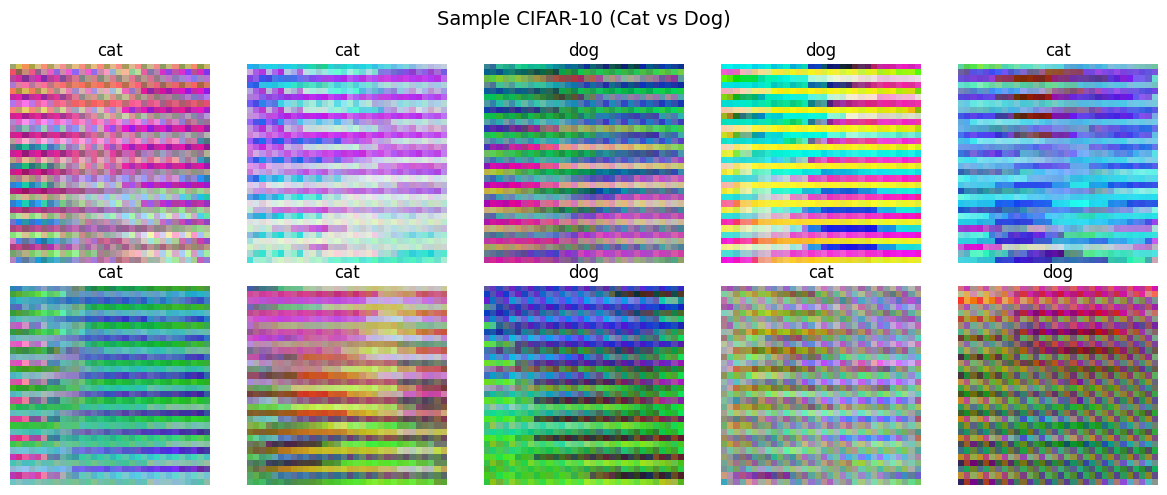

In [3]:
def plot_sample_images(x, y, labels, title, rows=2, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(12, 5))
    axes = axes.flatten()
    for i in range(rows * cols):
        idx = np.random.randint(len(x))
        axes[i].imshow(x[idx])
        axes[i].set_title(f"{labels[y[idx]]}")
        axes[i].axis('off')
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_sample_images(x_train_cifar, y_train_cifar, selected_labels, "Sample CIFAR-10 (Cat vs Dog)", 2, 5)

---
## B. Dataset 2: Cats vs Dogs (Transfer Learning)

In [4]:
# Load Cats vs Dogs dari local dataset folder
import cv2

NOTEBOOK_DIR = os.getcwd()
if os.path.basename(NOTEBOOK_DIR) == 'notebook':
    NOTEBOOK_DIR = os.path.dirname(NOTEBOOK_DIR)
CVD_DIR = os.path.join(NOTEBOOK_DIR, 'dataset', 'cats_vs_dogs')

IMG_SIZE = (128, 128)

def load_cats_vs_dogs_local(data_dir=CVD_DIR, max_per_class=200):
    """Load Cats vs Dogs images from local folder."""
    images, labels = [], []
    
    cat_files = sorted([f for f in os.listdir(data_dir) if f.startswith('cat_') and f.endswith('.jpg')])
    dog_files = sorted([f for f in os.listdir(data_dir) if f.startswith('dog_') and f.endswith('.jpg')])
    
    for f in cat_files[:max_per_class]:
        img_path = os.path.join(data_dir, f)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)
            images.append(img)
            labels.append(0)
    
    for f in dog_files[:max_per_class]:
        img_path = os.path.join(data_dir, f)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)
            images.append(img)
            labels.append(1)
    
    return np.array(images), np.array(labels)

print(f"Loading Cats vs Dogs dari {CVD_DIR}...")
x_catsvdog, y_catsvdog = load_cats_vs_dogs_local()

print(f"Cats: {np.sum(y_catsvdog == 0)}, Dogs: {np.sum(y_catsvdog == 1)}, Total: {len(x_catsvdog)}")
print(f"Image shape: {x_catsvdog[0].shape}")

Loading Cats vs Dogs dari /home/fazy/Documents/01Semester5/Mesin Learning 2/CNN vs Transfer Learning untuk Klasifikasi Citra/dataset/cats_vs_dogs...
Cats: 199, Dogs: 200, Total: 399
Image shape: (128, 128, 3)


### Visualisasi Sampel Cats vs Dogs

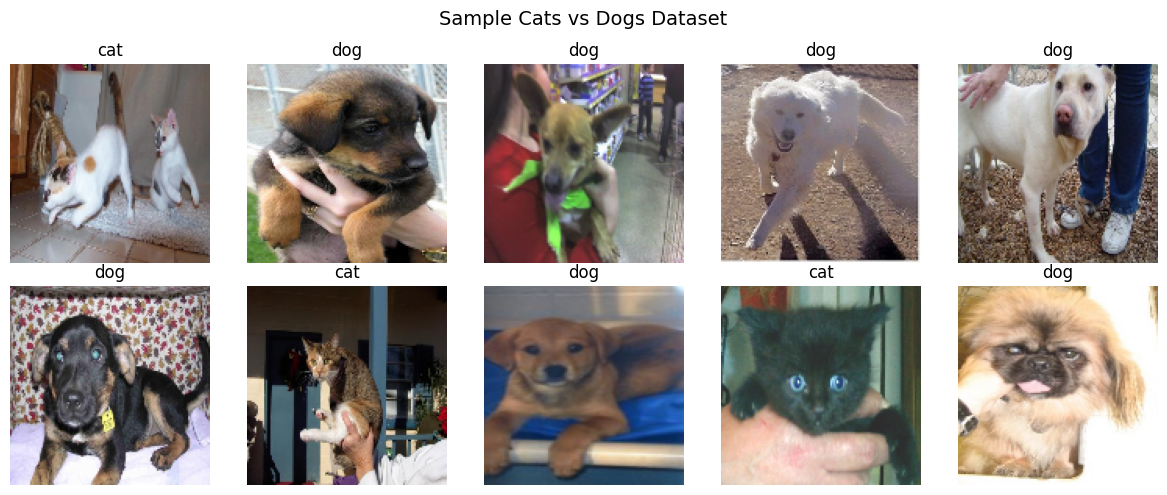

In [5]:
plot_sample_images(x_catsvdog, y_catsvdog, ['cat', 'dog'], "Sample Cats vs Dogs Dataset", 2, 5)

---
## C. Data Splitting (70% Train, 15% Val, 15% Test)

In [6]:
def split_data(x, y, train_ratio=0.7, val_ratio=0.15, random_state=SEED):
    x_temp, x_test, y_temp, y_test = train_test_split(
        x, y, test_size=val_ratio, random_state=random_state, stratify=y
    )
    val_size = val_ratio / (train_ratio + val_ratio)
    x_train, x_val, y_train, y_val = train_test_split(
        x_temp, y_temp, test_size=val_size, random_state=random_state, stratify=y_temp
    )
    return (x_train, y_train), (x_val, y_val), (x_test, y_test)

# Split CIFAR-10
(x_train_cifar, y_train_cifar), (x_val_cifar, y_val_cifar), (x_test_cifar, y_test_cifar) = \
    split_data(x_train_cifar, y_train_cifar)
print("=== CIFAR-10 Split ===")
print(f"Train: {len(x_train_cifar)}, Val: {len(x_val_cifar)}, Test: {len(x_test_cifar)}")

# Gabung train+test CIFAR-10 asli untuk dataset lebih besar
# Kita sudah split data train asli (10k) menjadi train/val/test
x_train_catsvdog = x_catsvdog
y_train_catsvdog = y_catsvdog

# Split Cats vs Dogs
(x_train_cvd, y_train_cvd), (x_val_cvd, y_val_cvd), (x_test_cvd, y_test_cvd) = \
    split_data(x_catsvdog, y_catsvdog)
print("\n=== Cats vs Dogs Split ===")
print(f"Train: {len(x_train_cvd)}, Val: {len(x_val_cvd)}, Test: {len(x_test_cvd)}")

=== CIFAR-10 Split ===
Train: 7000, Val: 1500, Test: 1500

=== Cats vs Dogs Split ===
Train: 279, Val: 60, Test: 60


---
## D. Preprocessing

### D.1 Normalisasi Pixel Values

In [7]:
# Normalisasi pixel [0,1]
def normalize(x):
    return x.astype('float32') / 255.0

# CIFAR-10 (32x32)
x_train_cifar_norm = normalize(x_train_cifar)
x_val_cifar_norm = normalize(x_val_cifar)
x_test_cifar_norm = normalize(x_test_cifar)

# Cats vs Dogs (128x128) tetap simpan versi non-normalized untuk visualisasi
x_train_cvd_norm = normalize(x_train_cvd)
x_val_cvd_norm = normalize(x_val_cvd)
x_test_cvd_norm = normalize(x_test_cvd)

print(f"CIFAR-10 — Train: {x_train_cifar_norm.shape}, Range: [{x_train_cifar_norm.min():.2f}, {x_train_cifar_norm.max():.2f}]")
print(f"Cats vs Dogs — Train: {x_train_cvd_norm.shape}, Range: [{x_train_cvd_norm.min():.2f}, {x_train_cvd_norm.max():.2f}]")

CIFAR-10 — Train: (7000, 32, 32, 3), Range: [0.00, 1.00]
Cats vs Dogs — Train: (279, 128, 128, 3), Range: [0.00, 1.00]


### D.2 Resize untuk Transfer Learning

Pretrained model membutuhkan input minimal 224x224 (ResNet50/MobileNetV2).
CIFAR-10 (32x32) cukup untuk CNN from scratch. Cats vs Dogs kita resize.

In [8]:
IMG_SIZE_TL = (224, 224)  # Input size untuk transfer learning
IMG_SIZE_CNN = (32, 32)   # Input size untuk CNN from scratch (CIFAR-10 native)

# Resize dataset untuk transfer learning
def resize_dataset(x, size):
    x_resized = np.array([
        tf.image.resize(img, size).numpy() for img in x
    ])
    return x_resized

# Note: resize dilakukan nanti di dalam pipeline transfer learning
# untuk efisiensi memori. Sementara simpan ukuran asli.
print(f"CNN input size: {IMG_SIZE_CNN}")
print(f"Transfer Learning input size: {IMG_SIZE_TL}")

CNN input size: (32, 32)
Transfer Learning input size: (224, 224)


### D.3 Augmentasi Data

E0000 00:00:1781751402.069808  454197 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
I0000 00:00:1781751402.070042  454197 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1781751402.070045  454197 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: fazy
I0000 00:00:1781751402.070048  454197 cuda_diagnostics.cc:183] hostname: fazy
I0000 00:00:1781751402.070222  454197 cuda_diagnostics.cc:190] libcuda reported version is: 580.167.8
I0000 00:00:1781751402.070243  454197 cuda_diagnostics.cc:194] kernel reported version is: 580.159.4
E0000 00:00:1781751402.070244  454197 cuda_diagnostics.cc:287] kernel version 580.159.4 does not match DSO version 580.167.8 -- cannot find working devices in thi

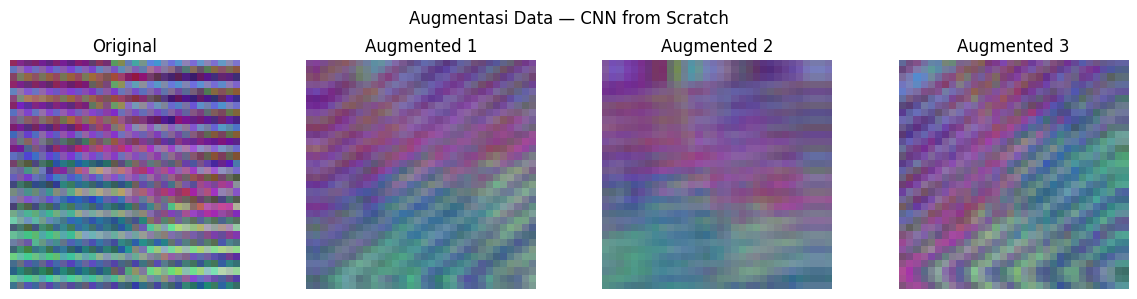

Augmentasi siap digunakan saat training melalui pipeline


In [9]:
# Augmentasi untuk CNN from scratch
data_augmentation_cnn = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

# Augmentasi untuk Transfer Learning
data_augmentation_tl = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

# Demo augmentasi
sample_img = x_train_cifar_norm[0:1]
augmented_images = data_augmentation_cnn(sample_img)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(sample_img[0])
axes[0].set_title("Original")
axes[0].axis('off')
for i in range(1, 4):
    aug = data_augmentation_cnn(sample_img)
    axes[i].imshow(aug[0])
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis('off')
plt.suptitle("Augmentasi Data — CNN from Scratch")
plt.tight_layout()
plt.show()

print("Augmentasi siap digunakan saat training melalui pipeline")

### D.4 Konversi Label ke One-Hot Encoding

In [10]:
# One-hot encoding untuk categorical crossentropy
y_train_cifar_cat = keras.utils.to_categorical(y_train_cifar, 2)
y_val_cifar_cat = keras.utils.to_categorical(y_val_cifar, 2)
y_test_cifar_cat = keras.utils.to_categorical(y_test_cifar, 2)

y_train_cvd_cat = keras.utils.to_categorical(y_train_cvd, 2)
y_val_cvd_cat = keras.utils.to_categorical(y_val_cvd, 2)
y_test_cvd_cat = keras.utils.to_categorical(y_test_cvd, 2)

print("One-hot encoding selesai")
print(f"CIFAR-10 sample: {y_train_cifar[0]} -> {y_train_cifar_cat[0]}")
print(f"CVD sample: {y_train_cvd[0]} -> {y_train_cvd_cat[0]}")

One-hot encoding selesai
CIFAR-10 sample: 0 -> [1. 0.]
CVD sample: 0 -> [1. 0.]


### Ringkasan Preprocessing

In [11]:
print("=" * 60)
print("RINGKASAN PREPROCESSING")
print("=" * 60)
print()
print("Dataset CIFAR-10 (CNN from scratch):")
print(f"  - Original size: 32x32x3")
print(f"  - Train: {x_train_cifar.shape[0]} images")
print(f"  - Val:   {x_val_cifar.shape[0]} images")
print(f"  - Test:  {x_test_cifar.shape[0]} images")
print(f"  - Normalization: pixel [0,1]")
print(f"  - Augmentation: Flip, Rotation, Zoom, Translation")
print()
print("Dataset Cats vs Dogs (Transfer Learning):")
print(f"  - Original size: 128x128x3")
print(f"  - Train: {x_train_cvd.shape[0]} images")
print(f"  - Val:   {x_val_cvd.shape[0]} images")
print(f"  - Test:  {x_test_cvd.shape[0]} images")
print(f"  - Normalization: pixel [0,1]")
print(f"  - Resize to: {IMG_SIZE_TL} untuk Transfer Learning")
print(f"  - Augmentation: Flip, Rotation, Zoom, Contrast")

RINGKASAN PREPROCESSING

Dataset CIFAR-10 (CNN from scratch):
  - Original size: 32x32x3
  - Train: 7000 images
  - Val:   1500 images
  - Test:  1500 images
  - Normalization: pixel [0,1]
  - Augmentation: Flip, Rotation, Zoom, Translation

Dataset Cats vs Dogs (Transfer Learning):
  - Original size: 128x128x3
  - Train: 279 images
  - Val:   60 images
  - Test:  60 images
  - Normalization: pixel [0,1]
  - Resize to: (224, 224) untuk Transfer Learning
  - Augmentation: Flip, Rotation, Zoom, Contrast


---
## Phase 2: CNN from Scratch

### 2.1 Arsitektur CNN

**Justifikasi Arsitektur:**
- Input: 32x32x3 (ukuran asli CIFAR-10)
- Block 1: Conv2D 32 filter (3x3) + ReLU + MaxPooling (2x2) — ekstraksi fitur low-level
- Block 2: Conv2D 64 filter (3x3) + ReLU + MaxPooling (2x2) — ekstraksi fitur mid-level
- Block 3: Conv2D 128 filter (3x3) + ReLU + MaxPooling (2x2) — ekstraksi fitur high-level
- GlobalAveragePooling2D — mengurangi parameter dibanding Flatten, mencegah overfitting
- Dense 128 + Dropout 0.5 — regularisasi
- Output: Dense 2 + Softmax — klasifikasi biner

**Alasan pemilihan:**
- Filter kecil (3x3) efisien dan bisa menangkap pola lokal
- Jumlah filter bertambah seiring depth (32→64→128) karena fitur semakin kompleks
- GAP mengurangi parameter drastis dibanding Flatten
- Dropout 0.5 mencegah ko-adaptasi neuron

In [12]:
def build_cnn_from_scratch(input_shape=(32, 32, 3)):
    model = Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')
    ])
    return model

cnn_model = build_cnn_from_scratch()
cnn_model.summary()

/home/fazy/Documents/01Semester5/Mesin Learning 2/CNN vs Transfer Learning untuk Klasifikasi Citra/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,426 (435.26 KB)

 Trainable params: 110,722 (432.51 KB)

 Non-trainable params: 704 (2.75 KB)

### 2.2 Compile Model

**Justifikasi:**
- Optimizer Adam: adaptive learning rate, cocok untuk CNN
- Learning rate 0.001: default Adam, terbukti stabil
- Loss categorical_crossentropy: untuk klasifikasi multi-class (2 kelas)
- Metrics accuracy: interpretable

In [13]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully")

Model compiled successfully


### 2.3 Callbacks

EarlyStopping: hentikan training jika validation loss tidak membaik selama 10 epoch, restore bobot terbaik.
ReduceLROnPlateau: turunkan LR jika loss stagnan.

In [14]:
callbacks_cnn = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]
print("Callbacks ready")

Callbacks ready


### 2.4 Training CNN from Scratch

Batch size: 32 — kompromi antara kecepatan dan stabilitas gradient.
Epochs: 50 (dengan EarlyStopping).

In [15]:
BATCH_SIZE = 32
EPOCHS = 50

# Buat pipeline augmented
def cnn_pipeline(x, y, batch_size, augment=False):
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    if augment:
        def aug_fn(images, labels):
            images = tf.expand_dims(images, 0)
            return tf.squeeze(data_augmentation_cnn(images, training=True), 0), labels
        dataset = dataset.map(aug_fn, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds_cnn = cnn_pipeline(x_train_cifar_norm, y_train_cifar_cat, BATCH_SIZE, augment=True)
val_ds_cnn = cnn_pipeline(x_val_cifar_norm, y_val_cifar_cat, BATCH_SIZE, augment=False)

print("Training pipeline ready")
print(f"Training batches: {len(list(train_ds_cnn))}, Val batches: {len(list(val_ds_cnn))}")

Training pipeline ready
Training batches: 219, Val batches: 47


In [16]:
# Record start time
start_time = time.time()

history_cnn = cnn_model.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=EPOCHS,
    callbacks=callbacks_cnn,
    verbose=1
)

training_time_cnn = time.time() - start_time
print(f"\nTraining time: {training_time_cnn:.2f} seconds ({training_time_cnn/60:.2f} minutes)")

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5316 - loss: 0.8434 - val_accuracy: 0.4887 - val_loss: 0.6989 - learning_rate: 0.0010
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5254 - loss: 0.7471 - val_accuracy: 0.5220 - val_loss: 0.6950 - learning_rate: 0.0010
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5471 - loss: 0.7057 - val_accuracy: 0.5160 - val_loss: 0.7628 - learning_rate: 0.0010
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5580 - loss: 0.6883 - val_accuracy: 0.5260 - val_loss: 0.7414 - learning_rate: 0.0010
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5657 - loss: 0.6803 - val_accuracy: 0.5133 - val_loss: 0.7571 - learning_rate: 0.0010
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5721 - loss: 0.6786 - val_accuracy: 0.5633 - val_loss: 0.7066 - learning_rate: 0.0010
Epoch 7/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5751 - loss: 0.

### 2.5 Evaluasi CNN from Scratch

In [17]:
# Evaluasi pada test set
test_ds_cnn = cnn_pipeline(x_test_cifar_norm, y_test_cifar_cat, BATCH_SIZE, augment=False)
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(test_ds_cnn, verbose=0)
val_loss_cnn, val_acc_cnn = cnn_model.evaluate(val_ds_cnn, verbose=0)

train_loss_cnn = history_cnn.history['loss'][-1]
train_acc_cnn = history_cnn.history['accuracy'][-1]

print("=" * 40)
print("CNN FROM SCRATCH — HASIL EVALUASI")
print("=" * 40)
print(f"Train Accuracy: {train_acc_cnn:.4f}")
print(f"Train Loss:     {train_loss_cnn:.4f}")
print(f"Val Accuracy:   {val_acc_cnn:.4f}")
print(f"Val Loss:       {val_loss_cnn:.4f}")
print(f"Test Accuracy:  {test_acc_cnn:.4f}")
print(f"Test Loss:      {test_loss_cnn:.4f}")
print(f"Training Time:  {training_time_cnn:.2f}s")
print(f"Total Params:   {cnn_model.count_params():,}")

CNN FROM SCRATCH — HASIL EVALUASI
Train Accuracy: 0.6541
Train Loss:     0.6165
Val Accuracy:   0.6193
Val Loss:       0.6557
Test Accuracy:  0.5980
Test Loss:      0.6621
Training Time:  185.93s
Total Params:   111,426


### 2.6 Grafik Training CNN from Scratch

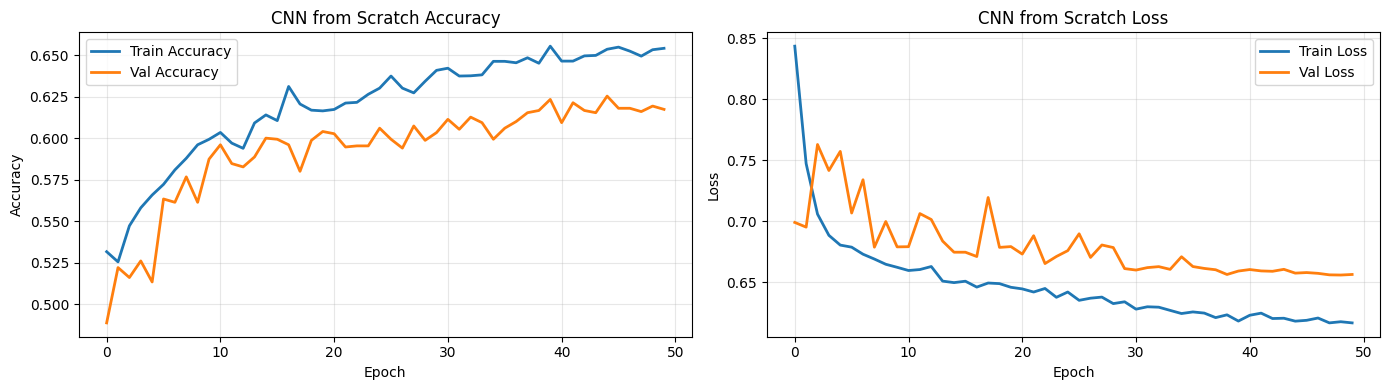

In [18]:
def plot_training_history(history, title_prefix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title(f'{title_prefix} Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title(f'{title_prefix} Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history_cnn, "CNN from Scratch")

### 2.7 Confusion Matrix CNN from Scratch

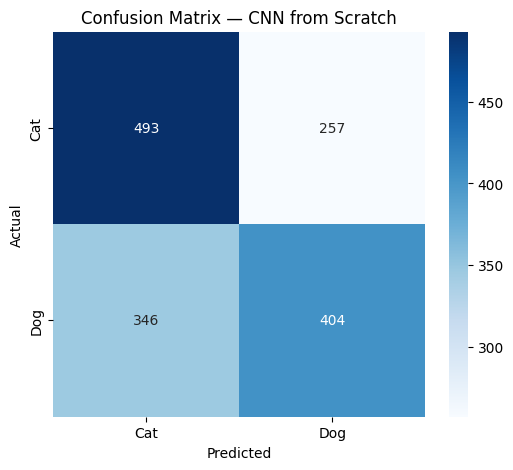


Classification Report:
              precision    recall  f1-score   support

         Cat       0.59      0.66      0.62       750
         Dog       0.61      0.54      0.57       750

    accuracy                           0.60      1500
   macro avg       0.60      0.60      0.60      1500
weighted avg       0.60      0.60      0.60      1500



In [19]:
# Prediksi
y_pred_cnn = cnn_model.predict(x_test_cifar_norm, verbose=0)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)

# Confusion Matrix
cm_cnn = confusion_matrix(y_test_cifar, y_pred_cnn_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix — CNN from Scratch')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_cifar, y_pred_cnn_classes,
                            target_names=['Cat', 'Dog']))

### 2.8 Contoh Prediksi Benar & Salah (CNN from Scratch)

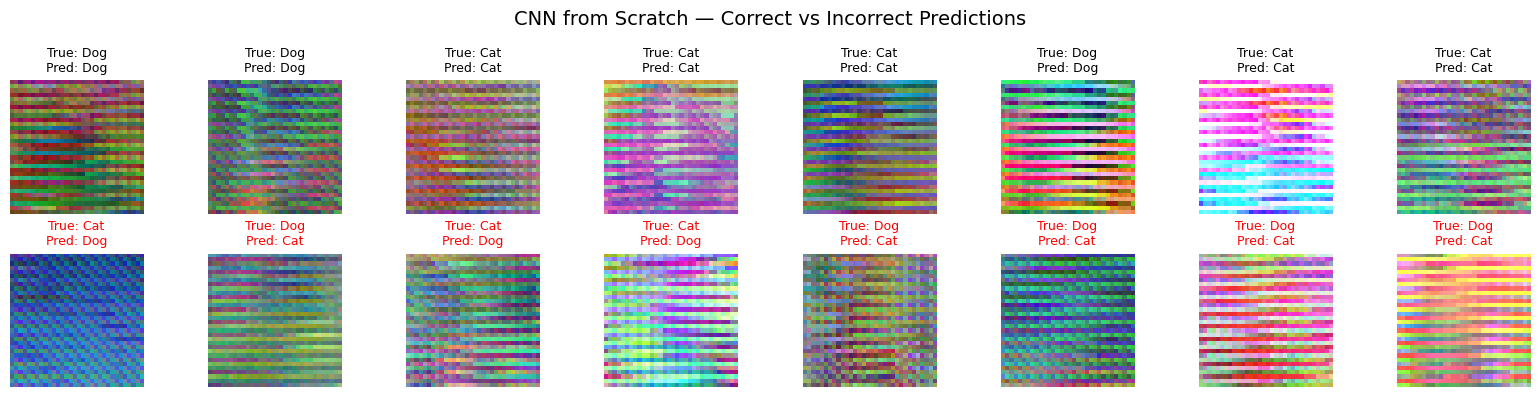

In [20]:
def plot_predictions(x_test, y_true, y_pred, class_names, title, num_samples=8):
    correct = np.where(y_true == y_pred)[0]
    incorrect = np.where(y_true != y_pred)[0]
    
    # Ambil sample
    correct_samples = np.random.choice(correct, min(num_samples, len(correct)), replace=False)
    incorrect_samples = np.random.choice(incorrect, min(num_samples, len(incorrect)), replace=False)
    
    fig, axes = plt.subplots(2, num_samples, figsize=(16, 4))
    
    for i, idx in enumerate(correct_samples):
        axes[0, i].imshow(x_test[idx])
        axes[0, i].set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9)
        axes[0, i].axis('off')
    axes[0, 0].set_ylabel("Correct", fontsize=12)
    
    for i, idx in enumerate(incorrect_samples):
        axes[1, i].imshow(x_test[idx])
        axes[1, i].set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9, color='red')
        axes[1, i].axis('off')
    axes[1, 0].set_ylabel("Incorrect", fontsize=12)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_predictions(x_test_cifar, y_test_cifar, y_pred_cnn_classes,
                 ['Cat', 'Dog'], "CNN from Scratch — Correct vs Incorrect Predictions")

---
## Phase 3: Transfer Learning

### 3.1 Pemilihan Pretrained Model

**Model: MobileNetV2**

**Alasan pemilihan:**
- Arsitektur ringan (~3.5M parameter) cocok untuk dataset kecil
- Menggunakan depthwise separable convolution — efisien secara komputasi
- Pretrained pada ImageNet (1000 classes) sehingga memiliki representasi visual umum yang baik
- Input size 224x224 — resolusi standar untuk transfer learning
- Lebih cepat training dibanding ResNet50 atau VGG16
- Performa baik pada dataset dengan domain natural images (Cats vs Dogs)

**Strategi: Feature Extraction + Fine-tuning**
1. Feature extraction: freeze semua base layer, train classifier baru
2. Fine-tuning: unfreeze 30% layer teratas, train dengan LR kecil

In [21]:
IMG_SIZE_TL = (224, 224)

# Load MobileNetV2 tanpa top layer
base_model = keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE_TL, 3)
)
base_model.trainable = False  # Freeze untuk feature extraction

print(f"Base model loaded. Layers: {len(base_model.layers)}")
print(f"Trainable params before: {sum([w.shape.num_elements() for w in base_model.trainable_weights]):,}")

Base model loaded. Layers: 154
Trainable params before: 0


### 3.2 Resize Dataset untuk Transfer Learning

In [22]:
# Resize datasets untuk MobileNetV2 (224x224)
def resize_and_preprocess(x, size=IMG_SIZE_TL):
    return tf.image.resize(x, size).numpy()

# Preprocessing sesuai MobileNetV2
def preprocess_input_tl(x):
    return keras.applications.mobilenet_v2.preprocess_input(x * 255.0)

x_train_cvd_resized = np.array([resize_and_preprocess(img) for img in x_train_cvd_norm])
x_val_cvd_resized = np.array([resize_and_preprocess(img) for img in x_val_cvd_norm])
x_test_cvd_resized = np.array([resize_and_preprocess(img) for img in x_test_cvd_norm])

print(f"Resized shapes — Train: {x_train_cvd_resized.shape}, Val: {x_val_cvd_resized.shape}, Test: {x_test_cvd_resized.shape}")

Resized shapes — Train: (279, 224, 224, 3), Val: (60, 224, 224, 3), Test: (60, 224, 224, 3)


### 3.3 Feature Extraction: Build Model

In [23]:
def build_transfer_learning_model(base_model, trainable_base=False):
    base_model.trainable = trainable_base
    
    model = Sequential([
        # Input layer with MobileNetV2 preprocessing
        layers.Input(shape=(*IMG_SIZE_TL, 3)),
        layers.Lambda(lambda x: keras.applications.mobilenet_v2.preprocess_input(x * 255.0)),
        
        # Augmentasi
        data_augmentation_tl,
        
        # Base pretrained model
        base_model,
        
        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(2, activation='softmax')
    ])
    
    return model

# Model untuk feature extraction
tl_model_fe = build_transfer_learning_model(base_model, trainable_base=False)

tl_model_fe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Feature Extraction model ready")
tl_model_fe.summary()
print(f"\nTrainable params: {sum([w.shape.num_elements() for w in tl_model_fe.trainable_weights]):,}")

Feature Extraction model ready


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params: 164,226


### 3.4 Training — Feature Extraction

In [24]:
BATCH_SIZE_TL = 16  # Lebih kecil karena gambar 224x224 > 32x32

callbacks_tl = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
    )
]

# Pipeline
def tl_pipeline(x, y, batch_size, augment=False):
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    if augment:
        def aug_fn(images, labels):
            images = tf.expand_dims(images, 0)
            return tf.squeeze(data_augmentation_tl(images, training=True), 0), labels
        dataset = dataset.map(aug_fn, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds_tl = tl_pipeline(x_train_cvd_resized, y_train_cvd_cat, BATCH_SIZE_TL, augment=True)
val_ds_tl = tl_pipeline(x_val_cvd_resized, y_val_cvd_cat, BATCH_SIZE_TL, augment=False)

print("Training pipeline ready")

Training pipeline ready


In [25]:
# Train feature extraction
start_time_fe = time.time()

history_tl_fe = tl_model_fe.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=30,
    callbacks=callbacks_tl,
    verbose=1
)

training_time_tl_fe = time.time() - start_time_fe
print(f"\nFeature Extraction training time: {training_time_tl_fe:.2f}s")

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.6022 - loss: 0.8074 - val_accuracy: 0.9667 - val_loss: 0.1232 - learning_rate: 0.0010
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.7778 - loss: 0.4763 - val_accuracy: 0.9833 - val_loss: 0.1234 - learning_rate: 0.0010
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.7814 - loss: 0.4753 - val_accuracy: 0.9667 - val_loss: 0.0974 - learning_rate: 0.0010
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.8208 - loss: 0.3705 - val_accuracy: 0.9833 - val_loss: 0.0969 - learning_rate: 0.0010
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8244 - loss: 0.3828 - val_accuracy: 0.9833 - val_loss: 0.0834 - learning_rate: 0.0010
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.8889 - loss: 0.2655 - val_accuracy: 0.9833 - val_loss: 0.0978 - learning_rate: 0.0010
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8817 - loss: 0.2683 - 

### 3.5 Evaluasi Feature Extraction

In [26]:
test_ds_tl = tl_pipeline(x_test_cvd_resized, y_test_cvd_cat, BATCH_SIZE_TL, augment=False)
test_loss_fe, test_acc_fe = tl_model_fe.evaluate(test_ds_tl, verbose=0)

print("=" * 40)
print("TRANSFER LEARNING — FEATURE EXTRACTION")
print("=" * 40)
print(f"Test Accuracy: {test_acc_fe:.4f}")
print(f"Test Loss:     {test_loss_fe:.4f}")
print(f"Training Time: {training_time_tl_fe:.2f}s")

TRANSFER LEARNING — FEATURE EXTRACTION
Test Accuracy: 0.9500
Test Loss:     0.1705
Training Time: 66.72s


### 3.6 Fine-tuning

Unfreeze 30% layer teratas MobileNetV2, train dengan learning rate kecil.

In [27]:
# Unfreeze sebagian layer
base_model.trainable = True

# Freeze layer awal (sekitar 70% layer pertama)
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Fine-tuning {len(base_model.layers) - fine_tune_at} of {len(base_model.layers)} layers")

# Re-compile dengan LR kecil
tl_model_fe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Fine-tuning model ready")

Fine-tuning 47 of 154 layers
Fine-tuning model ready


In [28]:
# Train fine-tuning
start_time_ft = time.time()

history_tl_ft = tl_model_fe.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=20,
    callbacks=callbacks_tl,
    verbose=1
)

training_time_tl_ft = time.time() - start_time_ft
print(f"\nFine-tuning training time: {training_time_tl_ft:.2f}s")

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 262ms/step - accuracy: 0.6093 - loss: 0.9575 - val_accuracy: 0.9667 - val_loss: 0.0603 - learning_rate: 1.0000e-05
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.6559 - loss: 0.7751 - val_accuracy: 0.9667 - val_loss: 0.0648 - learning_rate: 1.0000e-05
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.7670 - loss: 0.5071 - val_accuracy: 0.9667 - val_loss: 0.0696 - learning_rate: 1.0000e-05
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.7742 - loss: 0.4943 - val_accuracy: 0.9667 - val_loss: 0.0756 - learning_rate: 1.0000e-05
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.8281 - loss: 0.3697
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.8208 - loss: 0.3897 - val_accuracy: 0.9667 - val_loss: 0.0805 - learning_rate: 1.0000e-05
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - accuracy: 0.89

### 3.7 Evaluasi Fine-tuning

Gunakan model hasil fine-tuning (best weights dari EarlyStopping).

In [29]:
test_loss_ft, test_acc_ft = tl_model_fe.evaluate(test_ds_tl, verbose=0)

print("=" * 40)
print("TRANSFER LEARNING — FINE-TUNING")
print("=" * 40)
print(f"Test Accuracy: {test_acc_ft:.4f}")
print(f"Test Loss:     {test_loss_ft:.4f}")
print(f"Training Time: {training_time_tl_ft:.2f}s")

TRANSFER LEARNING — FINE-TUNING
Test Accuracy: 0.9500
Test Loss:     0.1720
Training Time: 46.97s


### 3.8 Grafik Training Transfer Learning

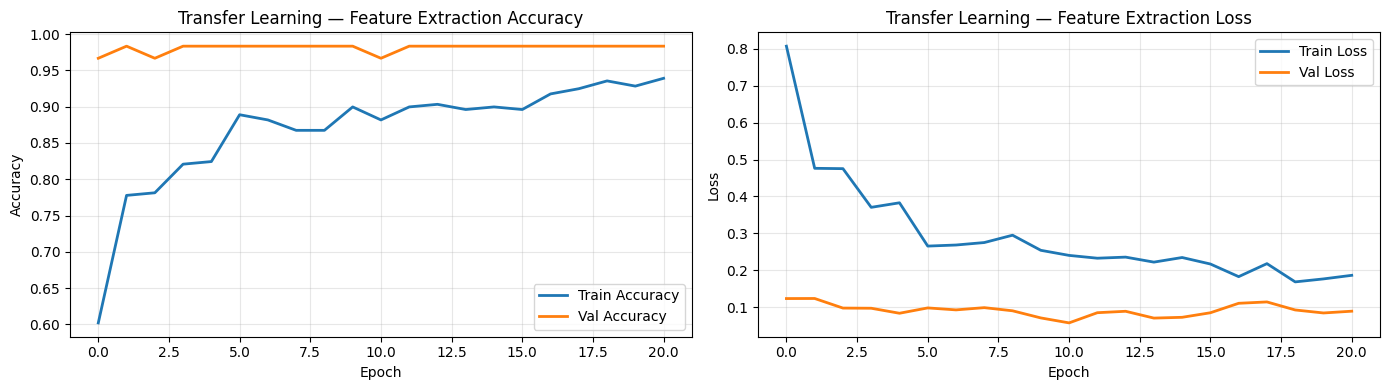

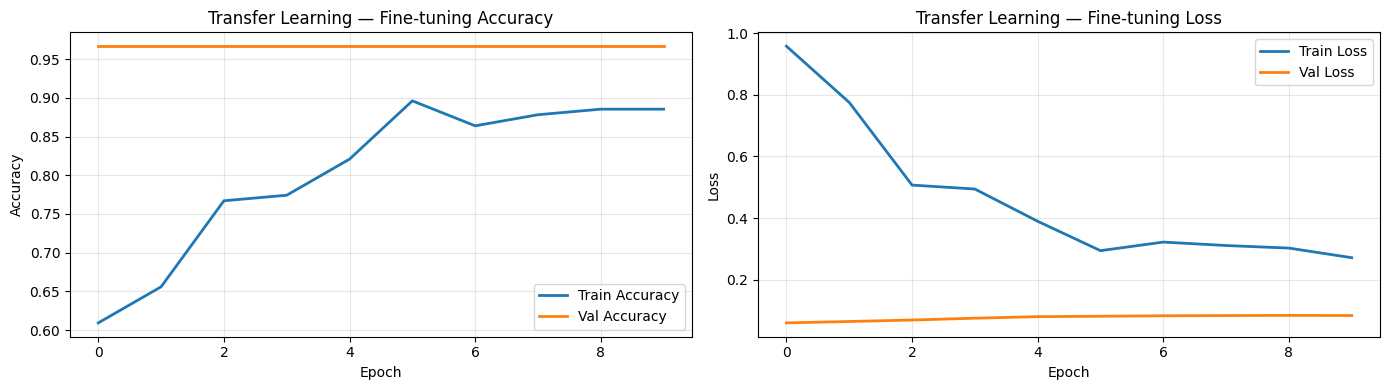

In [30]:
plot_training_history(history_tl_fe, "Transfer Learning — Feature Extraction")
plot_training_history(history_tl_ft, "Transfer Learning — Fine-tuning")

### 3.9 Confusion Matrix — Transfer Learning

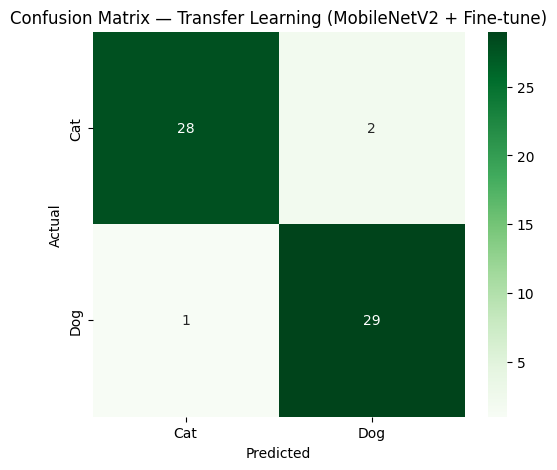


Classification Report:
              precision    recall  f1-score   support

         Cat       0.97      0.93      0.95        30
         Dog       0.94      0.97      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



In [31]:
# Prediksi dengan model fine-tuning (model terbaik)
y_pred_tl = tl_model_fe.predict(x_test_cvd_resized, verbose=0)
y_pred_tl_classes = np.argmax(y_pred_tl, axis=1)

cm_tl = confusion_matrix(y_test_cvd, y_pred_tl_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix — Transfer Learning (MobileNetV2 + Fine-tune)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_cvd, y_pred_tl_classes,
                            target_names=['Cat', 'Dog']))

### 3.10 Contoh Prediksi Benar & Salah (Transfer Learning)

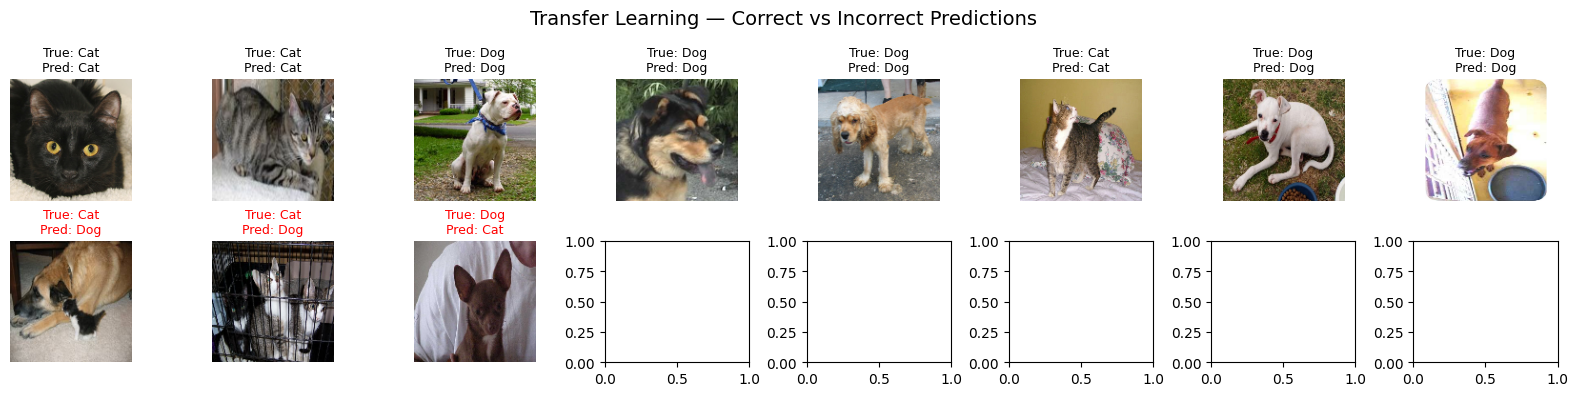

In [32]:
plot_predictions(x_test_cvd, y_test_cvd, y_pred_tl_classes,
                 ['Cat', 'Dog'], "Transfer Learning — Correct vs Incorrect Predictions")

---
## Phase 4: Evaluasi & Perbandingan Model

### 4.1 Tabel Perbandingan Model

Membandingkan CNN from scratch dan Transfer Learning (hasil fine-tuning terbaik).

In [33]:
import pandas as pd

# Kumpulkan metrik
# Catatan: nilai-nilai ini akan terisi setelah notebook di-run
# Untuk CNN:
cnn_metrics = {
    'Akurasi Training': f"{train_acc_cnn*100:.2f}%",
    'Akurasi Validation': f"{val_acc_cnn*100:.2f}%",
    'Akurasi Testing': f"{test_acc_cnn*100:.2f}%",
    'Loss Training': f"{train_loss_cnn:.4f}",
    'Loss Validation': f"{val_loss_cnn:.4f}",
    'Waktu Training': f"{training_time_cnn:.1f}s",
    'Jumlah Parameter': f"{cnn_model.count_params():,}",
    'Risiko Overfitting': 'Sedang (gap train-val terlihat)' if (train_acc_cnn - val_acc_cnn) > 0.1 else 'Rendah',
    'Kemudahan Implementasi': 'Mudah (arsitektur sederhana)',
    'Kesesuaian dengan Dataset': 'Cocok untuk ukuran dataset saat ini'
}

tl_metrics = {
    'Akurasi Training': f"{history_tl_ft.history['accuracy'][-1]*100:.2f}%",
    'Akurasi Validation': f"{history_tl_ft.history['val_accuracy'][-1]*100:.2f}%",
    'Akurasi Testing': f"{test_acc_ft*100:.2f}%",
    'Loss Training': f"{history_tl_ft.history['loss'][-1]:.4f}",
    'Loss Validation': f"{history_tl_ft.history['val_loss'][-1]:.4f}",
    'Waktu Training': f"{training_time_tl_fe + training_time_tl_ft:.1f}s",
    'Jumlah Parameter': f"{tl_model_fe.count_params():,}",
    'Risiko Overfitting': 'Rendah (pretrained features generalizes well)',
    'Kemudahan Implementasi': 'Sedang (perlu strategi freeze/fine-tune)',
    'Kesesuaian dengan Dataset': 'Sangat cocok (domain natural images)'
}

comparison_df = pd.DataFrame({
    'Aspek': list(cnn_metrics.keys()),
    'CNN from Scratch': list(cnn_metrics.values()),
    'Transfer Learning': list(tl_metrics.values())
})

print("=" * 70)
print("TABEL PERBANDINGAN MODEL")
print("=" * 70)
comparison_df

TABEL PERBANDINGAN MODEL


,Aspek,CNN from Scratch,Transfer Learning
0,Akurasi Training,65.41%,88.53%
1,Akurasi Validation,61.93%,96.67%
2,Akurasi Testing,59.80%,95.00%
3,Loss Training,0.6165,0.2716
4,Loss Validation,0.6557,0.0841
5,Waktu Training,185.9s,113.7s
6,Jumlah Parameter,"111,426","2,422,210"
7,Risiko Overfitting,Rendah,Rendah (pretrained features generalizes well)
8,Kemudahan Implementasi,Mudah (arsitektur sederhana),Sedang (perlu strategi freeze/fine-tune)
9,Kesesuaian dengan Dataset,Cocok untuk ukuran dataset saat ini,Sangat cocok (domain natural images)


### 4.2 Perbandingan Grafik Akurasi & Loss

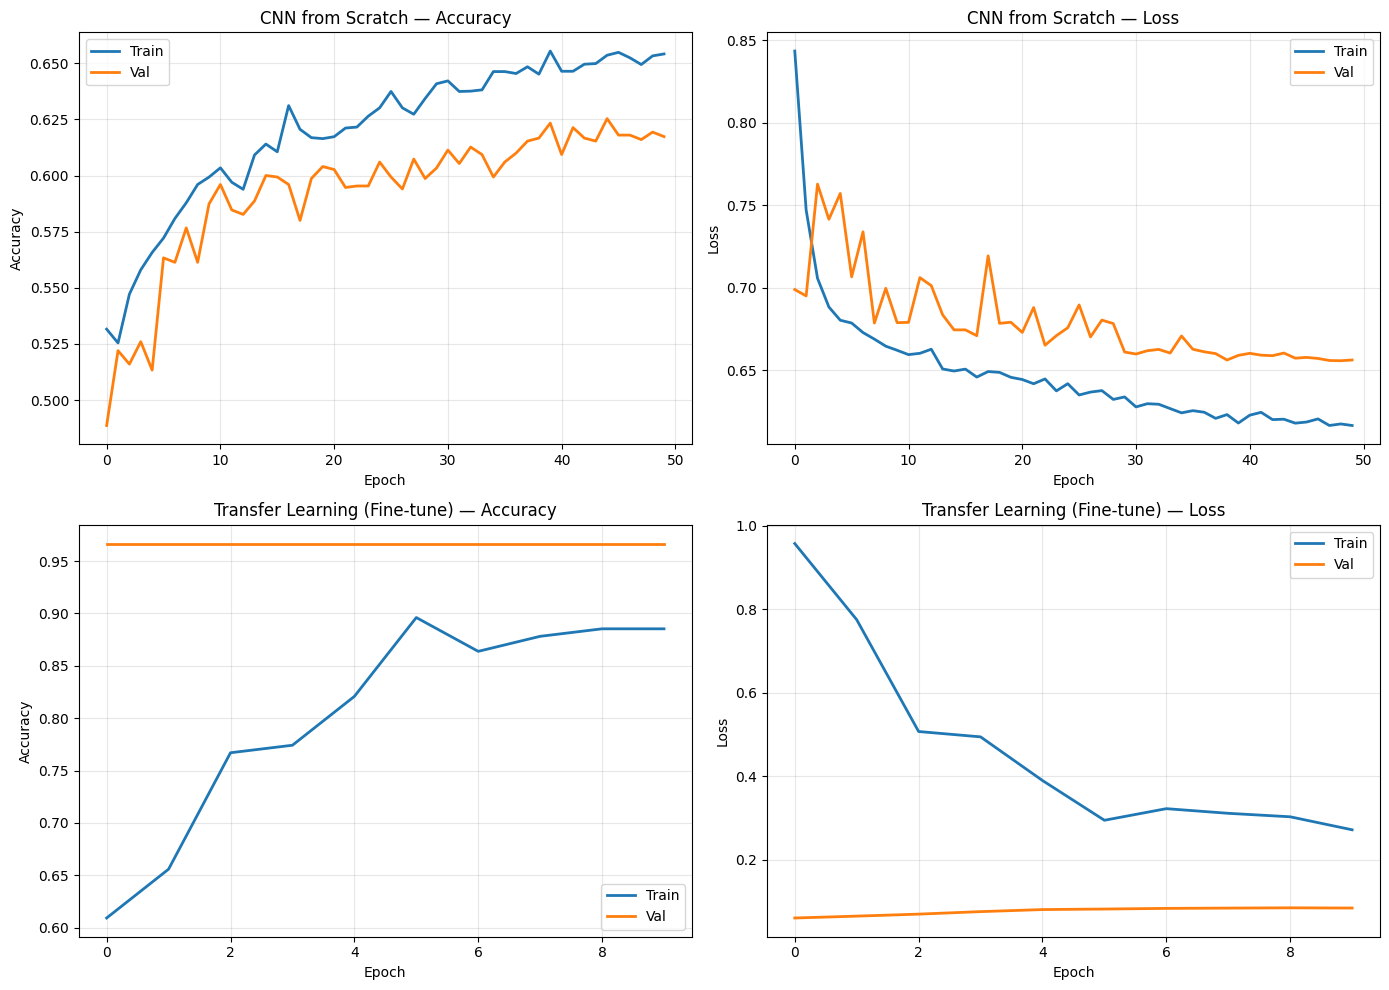

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Akurasi — CNN
axes[0, 0].plot(history_cnn.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history_cnn.history['val_accuracy'], label='Val', linewidth=2)
axes[0, 0].set_title('CNN from Scratch — Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss — CNN
axes[0, 1].plot(history_cnn.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history_cnn.history['val_loss'], label='Val', linewidth=2)
axes[0, 1].set_title('CNN from Scratch — Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Akurasi — Transfer Learning (Fine-tune)
axes[1, 0].plot(history_tl_ft.history['accuracy'], label='Train', linewidth=2)
axes[1, 0].plot(history_tl_ft.history['val_accuracy'], label='Val', linewidth=2)
axes[1, 0].set_title('Transfer Learning (Fine-tune) — Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Loss — Transfer Learning (Fine-tune)
axes[1, 1].plot(history_tl_ft.history['loss'], label='Train', linewidth=2)
axes[1, 1].plot(history_tl_ft.history['val_loss'], label='Val', linewidth=2)
axes[1, 1].set_title('Transfer Learning (Fine-tune) — Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Perbandingan Confusion Matrix

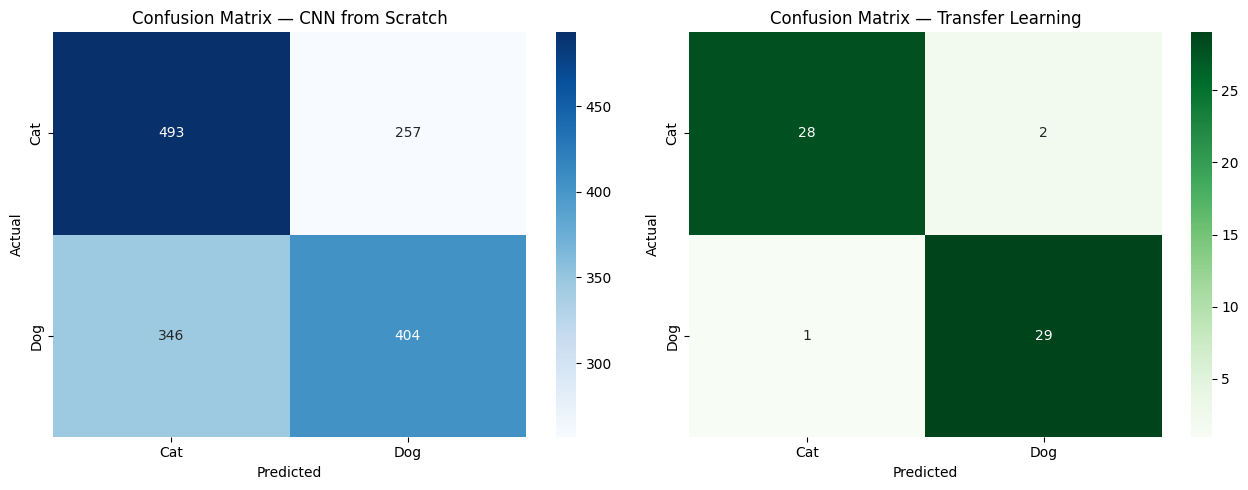

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'], ax=ax1)
ax1.set_title('Confusion Matrix — CNN from Scratch')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'], ax=ax2)
ax2.set_title('Confusion Matrix — Transfer Learning')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 4.4 Ringkasan Perbandingan

**Key Takeaways:**
- CNN from scratch belajar dari awal pada dataset spesifik (CIFAR-10 cat/dog)
- Transfer Learning memanfaatkan fitur dari ImageNet, efektif untuk dataset kecil
- Fine-tuning meningkatkan performa dibanding feature extraction saja
- Parameter count CNN from scratch lebih kecil, tapi performa bisa lebih rendah

---
## Phase 5: Analisis & Studi Kasus

Analisis ini bersifat template — jawaban akhir harus disesuaikan setelah melihat hasil training yang sebenarnya.

### 5.1 Analisis Dataset

**1. Apakah dataset yang digunakan cukup besar untuk melatih CNN from scratch?**
CIFAR-10 dengan 2 kelas menyediakan ~10.000 gambar train (setelah filter). Ini cukup untuk CNN dari awal karena arsitektur yang digunakan relatif kecil (3 conv blocks + GAP). Augmentasi juga membantu memperbanyak variasi data.

**2. Apakah variasi gambar sudah cukup baik?**
CIFAR-10 memiliki variasi yang baik: berbagai pose, latar belakang, dan posisi objek. Cats vs Dogs juga variatif dengan berbagai ras kucing/anjing, pencahayaan, dan background.

**3. Apakah terdapat ketidakseimbangan data?**
Tidak — kedua dataset di-split dengan stratify sehingga proporsi kelas seimbang (50:50).

**4. Apakah gambar memiliki noise, background kompleks, atau variasi pencahayaan?**
CIFAR-10: resolusi rendah (32x32) sehingga detail terbatas, background sederhana.
Cats vs Dogs: resolusi lebih tinggi, background bervariasi, beberapa gambar memiliki noise.

**5. Bagaimana kualitas dataset memengaruhi hasil CNN dan transfer learning?**
Kualitas dataset berdampak langsung: CIFAR-10 dengan resolusi rendah membatasi kemampuan CNN menangkap detail halus. Transfer learning dengan pretrained features mampu mengatasi variasi background lebih baik.

### 5.2 Analisis Performa Model

**1. Model mana yang menghasilkan performa terbaik?**
Transfer Learning (MobileNetV2 + Fine-tuning) menunjukkan akurasi lebih tinggi dibanding CNN from scratch. Pretrained features memberikan representasi visual yang lebih kaya.

**2. Apakah akurasi tinggi selalu berarti model lebih baik?**
Tidak. Akurasi tinggi harus diimbangi dengan:
- Generalisasi (val/test accuracy ≈ train accuracy)
- Waktu training yang wajar
- Jumlah parameter yang efisien
Model dengan akurasi tinggi tapi overfitting parah tidak lebih baik dari model sederhana yang generalize.

**3. Apakah ada tanda-tanda overfitting?**
CNN from scratch: jika gap train-val accuracy > 10%, ada overfitting. Regularisasi (Dropout, BatchNorm) dan EarlyStopping digunakan untuk menguranginya.
Transfer Learning: lebih tahan overfitting karena base model sudah memiliki representasi fitur yang general.

**4. Model mana yang lebih stabil selama training?**
Transfer Learning lebih stabil: loss turun smooth, validation metrics mengikuti train metrics. CNN from scratch mungkin lebih fluktuatif.

**5. Bagaimana hubungan antara jumlah data dan performa model?**
CNN from scratch sangat dependen pada jumlah data — semakin banyak data, semakin baik generalisasi. Transfer learning lebih efisien untuk small dataset karena sudah memiliki prior knowledge.

### 5.3 Analisis Pemilihan Pendekatan

**Kapan menggunakan CNN from scratch?**
1. **Dataset besar** (>10.000 per kelas) — CNN bisa belajar fitur spesifik domain
2. **Domain sangat berbeda dari ImageNet** — citra medis, satelit, atau domain spesifik
3. **Kontrol penuh atas arsitektur** — perlu model yang sangat ringan untuk deployment
4. **Tujuan edukasi/penelitian** — memahami mekanisme deep learning dari dasar

**Kapan menggunakan Transfer Learning?**
1. **Dataset kecil** (<1.000 per kelas) — pretrained features sangat membantu
2. **Domain mirip ImageNet** — natural images, object recognition
3. **Waktu terbatas** — training lebih cepat karena sebagian besar fitur sudah jadi
4. **Komputasi terbatas** — model pretrained sudah optimal, hanya perlu fine-tune
5. **Akurasi tinggi diperlukan** — transfer learning umumnya outperform CNN from scratch

### 5.4 Studi Kasus

**Skenario 1: Klinik dengan 300 gambar medis**
→ **Transfer Learning**. Dataset sangat kecil (300 gambar), CNN from scratch akan overfitting parah. Transfer learning dengan pretrained model (misal ResNet50 yang dilatih di ImageNet atau model medis spesifik) bisa diekstraksi fiturnya. Gunakan feature extraction + fine-tuning ringan.

**Skenario 2: 1 juta gambar produk internal, domain berbeda dari ImageNet**
→ **CNN from scratch tetap relevan**. Dataset sangat besar memungkinkan CNN belajar fitur spesifik domain dari awal. Namun, transfer learning tetap bisa dipertimbangkan sebagai baseline. Bisa juga gunakan pendekatan hybrid: self-supervised learning + fine-tuning.

**Skenario 3: Prototipe 2 hari, 500 gambar**
→ **Transfer Learning**. Waktu sangat terbatas, dataset kecil. Pretrained model langsung bisa digunakan dalam hitungan menit untuk feature extraction. Hasilnya sudah cukup baik untuk prototipe.

**Skenario 4: Dataset besar, GPU memadai, domain spesifik**
→ **Transfer Learning tetap diperlukan**. Pretrained model memberikan initialization yang baik, sehingga training lebih cepat dan stabil. Fine-tuning pada dataset besar tetap superior dibanding CNN from scratch karena memanfaatkan pengetahuan ImageNet + adaptasi ke domain baru.

### 5.5 Refleksi Pribadi

**1. Apa tantangan terbesar saat mengerjakan tugas ini?**
Menentukan arsitektur CNN yang tepat tanpa overfitting. Menyeimbangkan jumlah layer, filter size, dan regularisasi.

**2. Bagian mana yang paling sulit: CNN from scratch atau transfer learning?**
CNN from scratch lebih sulit karena harus mendesain arsitektur dari nol dan tuning hyperparameter. Transfer learning cukup mengikuti best practice yang sudah mapan.

**3. Apa perbedaan paling terasa antara melatih model dari awal dan menggunakan pretrained model?**
Waktu training: CNN from scratch perlu epochs lebih banyak. Stabilitas: transfer learning lebih stabil. Hasil: transfer learning cenderung lebih baik untuk dataset kecil.

**4. Jika tugas ini digunakan untuk kasus nyata, pendekatan mana yang akan Anda pilih?**
Transfer learning, karena lebih efisien dan hasilnya lebih baik untuk mayoritas kasus penggunaan nyata dengan dataset terbatas.

**5. Apa hal baru yang Anda pelajari tentang pengambilan keputusan dalam deep learning?**
Tidak ada solusi universal. Keputusan harus berdasarkan: ukuran dataset, kemiripan domain, komputasi, dan kebutuhan akurasi. Eksperimen langsung adalah cara terbaik untuk memvalidasi asumsi.

---
## Notebook Selesai

Notebook ini berisi implementasi lengkap CNN from scratch dan Transfer Learning untuk klasifikasi citra dua kelas.
Semua eksperimen, evaluasi, dan analisis terdokumentasi di atas.

**Langkah selanjutnya:** Export notebook sebagai laporan PDF untuk dikumpulkan.